In [1]:
include("MiniCollectiveSpins.jl")
include("Functions_time_evol_boxes.jl")
using PyPlot
using Statistics
using JLD2
using OrdinaryDiffEq

### Define the system

In [23]:
# Nbr of particles
N = 5
r = 100
d0_lb = 1e-10 # Minimum distance between the atoms (lower boundary) in m
λ = 421e-9
γ = 32.7e6 # In Hz
sat = [35;]
Ω_RO = γ.*sqrt.(sat/2)
n0 = 100

# Quantization axis along z
e = [0, 0, 1.]

# Normalisation
d0_lb = d0_lb / λ
Ω_RO = Ω_RO / γ
γ = 1.

t_end = 1e2

window_t, window_var = 2, 4
threshold_box = 1e-5; # Time over which the boxes are computed

# Plots of the time evolution

In [24]:
close("all")
fig, ax = subplots()
list_t_N_no_SF, popup_t_N_no_SF, nbr_error_t_N_no_SF, sol_t_N_no_SF = [], [], [], []

for (i, s) in ProgressBar(enumerate(sat))
    line = []
    @load "solutions/sol_N_$(N)_r_$(r)_sat_$(s)_n0_$(n0)_without_SF.jld2" sol_tasks
    list_t_no_SF, popup_t_no_SF, nbr_error_no_SF, sol_t_no_SF =  [vcat([s[i] for s in sol_tasks]...) for i = 1:4]
    push!(list_t_N_no_SF, list_t_no_SF), push!(popup_t_N_no_SF, popup_t_no_SF), push!(nbr_error_t_N_no_SF, nbr_error_no_SF), push!(sol_t_N_no_SF, sol_t_no_SF)
    for j in 1:length(popup_t_no_SF)
        # if j ∉ nbr_error
            if line == []
                line, = ax.plot(list_t_no_SF[j], popup_t_no_SF[j], label="sat=$(s)") # N_list[i] , marker="o", markersize=1,
            else
                ax.plot(list_t_no_SF[j], popup_t_no_SF[j], color=line.get_color()) # marker="o", markersize=1,
            end
        # end
    end
end

ax.set_xlabel(L"$\gamma t$")
ax.set_ylabel(L"$\langle  N_{\uparrow} \rangle $")
ax.set_ylim(0, 10)
ax.legend()

suptitle("N = $N, r = $r, "*L"$n_0$"*" = $n0, Starting from "*L"$|\downarrow \downarrow \rangle $")
pygui(false); gcf();
# pygui(true); show()

0.0%┣                                                ┫ 0/1 [00:00<00:00, -0s/it]
┌ Warning: Opening file with JLD2.MmapIO failed, falling back to IOStream
└ @ JLD2 C:\Users\Joschka\.julia\packages\JLD2\WDhXU\src\JLD2.jl:162


LoadError: SystemError: opening file "solutions/sol_N_5_r_100_sat_35_n0_100_without_SF.jld2": No such file or directory

0.0%┣                                                ┫ 0/1 [00:00<00:00, -0s/it]
100.0%┣██████████████████████████████████████████┫ 1/1 [00:00<Inf:Inf, InfGs/it]
100.0%┣██████████████████████████████████████████┫ 1/1 [00:00<Inf:Inf, InfGs/it]


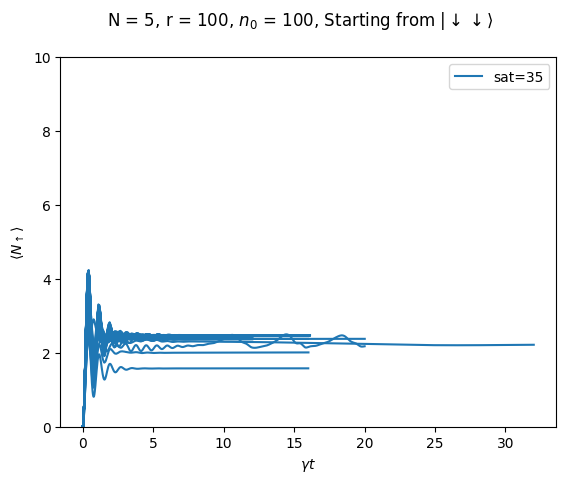

In [25]:
close("all")
fig, ax = subplots()
list_t_N, popup_t_N, nbr_error_t_N, sol_t_N = [], [], [], []

for (i, s) in ProgressBar(enumerate(sat))
    line = []
    @load "solutions/sol_N_$(N)_r_$(r)_sat_$(s)_n0_$(n0).jld2" sol_tasks
    list_t, popup_t, nbr_error, sol_t =  [vcat([s[i] for s in sol_tasks]...) for i = 1:4]
    push!(list_t_N, list_t), push!(popup_t_N, popup_t), push!(nbr_error_t_N, nbr_error), push!(sol_t_N, sol_t)
    for j in 1:length(popup_t)
        if j ∉ nbr_error
            if line == []
                line, = ax.plot(list_t[j], popup_t[j], label="sat=$(s)") # N_list[i] , marker="o", markersize=1,
            else
                ax.plot(list_t[j], popup_t[j], color=line.get_color()) # marker="o", markersize=1,
            end
        end
    end
end

ax.set_xlabel(L"$\gamma t$")
ax.set_ylabel(L"$\langle  N_{\uparrow} \rangle $")
ax.set_ylim(0, 10)
ax.legend()

suptitle("N = $N, r = $r, "*L"$n_0$"*" = $n0, Starting from "*L"$|\downarrow \downarrow \rangle $")
pygui(false); gcf();
# pygui(true); show()

### Compare with/without $H_{SF}$

0.0%┣                                                ┫ 0/1 [00:00<00:00, -0s/it]
100.0%┣██████████████████████████████████████████┫ 1/1 [00:00<Inf:Inf, InfGs/it]
100.0%┣██████████████████████████████████████████┫ 1/1 [00:00<Inf:Inf, InfGs/it]


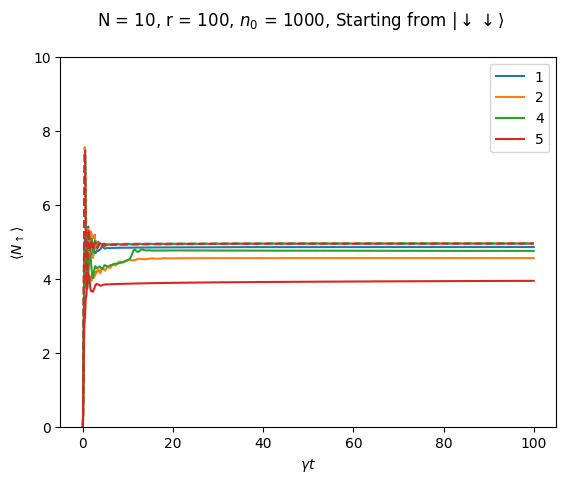

In [5]:
close("all")
fig, ax = subplots()

for (i, s) in ProgressBar(enumerate(sat))
    for j in 1:5
        if j ∉ nbr_error_t_N[i]
            line, = ax.plot(list_t_N[i][j], popup_t_N[i][j], label="$j")
            ax.plot(list_t_N_no_SF[i][j], popup_t_N_no_SF[i][j], color=line.get_color(), linestyle="--")
        end
    end
end

ax.legend()

ax.set_xlabel(L"$\gamma t$")
ax.set_ylabel(L"$\langle  N_{\uparrow} \rangle $")
ax.set_ylim(0, 10)

suptitle("N = $N, r = $r, "*L"$n_0$"*" = $n0, Starting from "*L"$|\downarrow \downarrow \rangle $")
pygui(false); gcf();
# pygui(true); show()

# Try to find issue

In [32]:
i=34
N=5
@load "r0/r0_N_$(N)_r_$(nbr_error_t_N[1][1]).jdl2" r0 L
r0
min_r0(r0) * λ

2.107239014125314e-8

In [33]:
### Define the system ###
# Nbr of particles
N_list = [5;]
r = 100
sat = [35;]
n0 = 100 # Atoms/λ^-3 (density already integrated along z)

# Normalisation parameters
λ = 421e-9
γ = 32.7e6 # In Hz

# Physical values
ω0 = (2π*ustrip(c_0)/λ)
ωl = ω0
kl = [2π/λ, 0, 0] # Laser along x
Ω_RO = γ*sqrt.(sat/2)

d0_lb = 1e-10 # Minimum distance between the atoms (lower boundary) in m

# Normalization
ω0 = ω0 / γ
ωl = ωl / γ
kl = kl * λ 
Ω_RO = Ω_RO / γ
d0_lb = d0_lb / λ

0.00023752969121140142

In [34]:
d0_lb * λ

1.0e-10

In [35]:
system = SpinCollection(r0, e, gammas=1.)
Ω_CS = OmegaMatrix(system)
Γ_CS = GammaMatrix(system)
Γij_ = [Γ_CS[i, j] for i = 1:N for j=1:N]
Ωij_ = [Ω_CS[i, j] for i = 1:N for j=1:N if i≠j] #* 0
exp_RO_ = [exp(1im*r0[i]'kl) for i = N:-1:1] # We go in the decreasing direction to avoid exp_RO(10) being replace by exp_RO(1)0
conj_exp_RO_ = [exp(-1im*r0[i]'kl) for i = N:-1:1]
p0 = ComplexF64.([Γij_; Ωij_; exp_RO_; conj_exp_RO_; Ω_RO]);

In [36]:
# Prepare the wrapper
const N_FUNCS = length(N_list)  # Total function nbr
const functs = Vector{Function}(undef, N_FUNCS)

for (i, N) in enumerate(N_list)
    libpath ="libs/liballfuncs_$N.dll"
    functs[i] = load_f("diffeqf", libpath)
end

In [37]:
@load "op_list/op_list_$N.jdl2" op_list
phi_array_0, theta_array_0 = zeros(N), ones(N)*π # We start from all the atoms in the GS
u0 = u0_CFunction(phi_array_0, theta_array_0, op_list)
# Load the functions
fsolve(du, u, p, t) = functs[1](du, u, p0)

fsolve (generic function with 1 method)

In [48]:
maximum(abs.(p0))

11.548281544850882

In [47]:
minimum(abs.(p0))

0.2310912161878713

In [40]:
prob = OrdinaryDiffEq.ODEProblem(fsolve, u0, (0, 1e3))

sol = OrdinaryDiffEq.solve(prob, OrdinaryDiffEq.DP5())#, adaptive=false, dt=1e-5);
σz = [2*sol.u[i][1:N] .- (1+0im) for i=1:length(sol.t)] 
σx = [sol.u[i][N+1:2*N] .+ conj.(sol.u[i][N+1:2*N]) for i=1:length(sol.t)]
σy = [-1im*sol.u[i][N+1:2*N] .+ 1im*conj.(sol.u[i][N+1:2*N]) for i=1:length(sol.t)];

In [41]:
Ω_CS

5×5 Matrix{Float64}:
  0.0       -0.231091  11.5483    -0.954451   5.95033
 -0.231091   0.0       -0.848781   2.29937   -0.538988
 11.5483    -0.848781   0.0       -1.55718   11.3822
 -0.954451   2.29937   -1.55718    0.0       -4.32403
  5.95033   -0.538988  11.3822    -4.32403    0.0

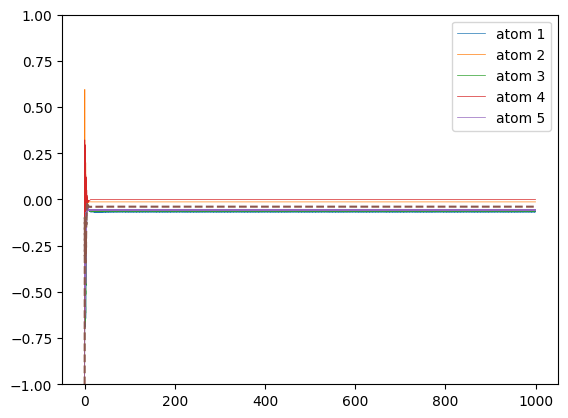

false

In [43]:
close("all")

for j = 1:5
    plot(sol.t, real.([σz[i][j] for i = 1:length(sol.t)]), linewidth=0.5, label="atom $j")
end

legend()

plot(sol.t, sum([real.([σz[i][j] for i = 1:length(sol.t)]) for j=1:5])/N, linestyle="--")

ylim(-1, 1)
# pygui(true); show()
pygui(false)

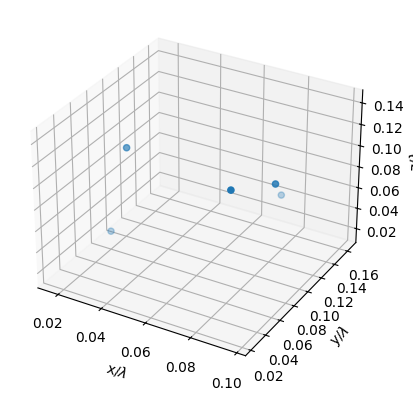

In [49]:
close("all")
fig = plt.figure()
ax = fig.add_subplot(projection="3d")
ax.scatter([r[1] for r in r0], [r[2] for r in r0], [r[3] for r in r0])
ax.set_xlabel(L"x/$\lambda$")
ax.set_ylabel(L"y/$\lambda$")
ax.set_zlabel(L"z/$\lambda$")
# ax.grid("off")
plt.show()
pygui(false);
#pygui(true); show()

In [ ]:
plot(sol.t, [sum(real(sol.u[i][1:N])) for i=1:length(sol.t)])
ylim(0, 10)

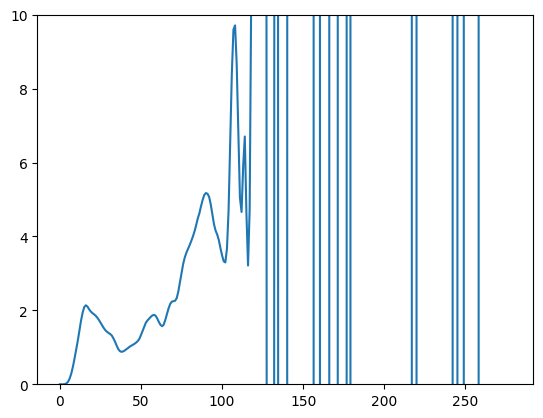

(0.0, 10.0)

In [46]:
plot(popup_t_N[1][i])
ylim(0, 10)

In [ ]:
close("all")
fig, ax = subplots()

for (i, s) in ProgressBar(enumerate(sat))
    line = []
    for j in 1:10#length(popup_t_N[i])
        if j in nbr_error_t_N[i]
            if line == []
                line, = ax.plot(list_t_N[i][j], popup_t_N[i][j] / N, label="sat=$(s)") # N_list[i] , marker="o", markersize=1,
            else
                ax.plot(list_t_N[i][j], popup_t_N[i][j] / N, color=line.get_color()) # marker="o", markersize=1,
            end
        end
    end
end

ax.set_xlabel(L"$\gamma t$")
ax.set_ylabel(L"$\langle  n_{\uparrow} \rangle $")
ax.legend()

suptitle("N = $N, r = $r, "*L"$n_0$"*" = $n0, Starting from "*L"$|\downarrow \downarrow \rangle $")
pygui(false); gcf();
# pygui(true); show()

# Mean of the SS

In [ ]:
# For sat = 0, only throws errors as density to close from 0 --> remove the errors 
if 0 ∈ sat
    idx = findall(sat .== 0)[1]
    for i in 1:length(nbr_error_t_N[idx])
        if maximum(abs.(popup_t_N[idx][nbr_error_t_N[idx][i]])) < 10
            nbr_error_t_N[idx][i] = 0 # Physical solution
        end
    end
end

mean_SS = mean.([[popup_t_N[i][j][end] for j = 1:length(popup_t_N[i]) if j ∉ nbr_error_t_N[i]] for i = 1:length(popup_t_N)])
std_SS = std.([[popup_t_N[i][j][end] for j = 1:length(popup_t_N[i]) if j∉nbr_error_t_N[i]] for i = 1:length(popup_t_N)])

fig, axes = subplots(1, 2, figsize = (15, 5))
axes[1].errorbar(sat, mean_SS, yerr=std_SS ./ sqrt.([length(popup_t_N[i])-length(nbr_error_t_N[i]) for i = 1:length(sat)]))
axes[1].set_xlabel(L"s")
axes[1].set_ylabel(L"$\langle  N_{\uparrow}^{SS} \rangle $")

axes[2].errorbar(sat, mean_SS./N, yerr=std_SS ./ (N .* sqrt.([length(popup_t_N[i])-length(nbr_error_t_N[i]) for i = 1:length(sat)])))
axes[2].set_xlabel(L"s")
axes[2].set_ylabel(L"$\langle  n_{\uparrow}^{SS} \rangle $")


pygui(false); gcf();
# pygui(true); show()

# Comparison with spontaneous emission

In [ ]:
function deriv_indep_atoms(du, u, p, t)
    γ, Ω = p[1], p[2]
    du[1] = -2γ*u[1] + 1im*Ω*(u[2]-conj(u[2])) # u[1] = ρee, u[2] = ρeg
    du[2] = -γ*u[2] + 1im*Ω*(2*u[1]-1)
end

# Fit the independant case to the SS interacting case

In [ ]:
function fit_γ_SE(n_up_SS, Ω)
    return Ω*sqrt(1/n_up_SS - 2)
end

In [ ]:
close("all")
fig, ax = subplots()

u0_indep = zeros(ComplexF64, 2)
decay_rate_interactions_eq_indep = zeros((length(sat), r))


for (i, s) in enumerate(sat)
    line = []
    for j in 1:length(popup_t_N[i])
        if j ∉ nbr_error_t_N[i]
            if line == []
                line, = ax.plot(list_t_N[i][j], popup_t_N[i][j] ./ N, label="sat=$(s)") # N_list[i] , marker="o", markersize=1,
            else
                ax.plot(list_t_N[i][j], popup_t_N[i][j] ./ N, color=line.get_color()) # marker="o", markersize=1,
            end

            if popup_t_N[i][j][end] > 0
                γ_fit_SE = fit_γ_SE(popup_t_N[i][j][end]/N, Ω_RO[i])
                prob = ODEProblem(deriv_indep_atoms, u0_indep, (0, t_end), [γ_fit_SE, Ω_RO[i]])
                sol_indep = solve(prob)
                plot(sol_indep.t, real([sol[1] for sol in sol_indep.u]), linestyle="--", color=line.get_color())

                decay_rate_interactions_eq_indep[i, j] = γ_fit_SE
            end
        end
    end
end

ax.set_xlabel(L"$\gamma t$")
ax.set_ylabel(L"$\langle  n_{\uparrow} \rangle $")
ax.legend()

suptitle("N = $N, r = $r, "*L"$n_0$"*" = $n0, Starting from "*L"$|\downarrow \downarrow \rangle $")
pygui(false); gcf();
# pygui(true); show()

In [ ]:
close("all")
fig = subplots()

errorbar(sat, [mean([decay_rate_interactions_eq_indep[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(sat)], yerr=[std([decay_rate_interactions_eq_indep[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]])/sqrt(r) for i in 1:length(sat)])

for (i, s) in enumerate(sat)
    for j in 1:r
        if j ∉ nbr_error_t_N[i]
            scatter(s, decay_rate_interactions_eq_indep[i, j], color="blue", alpha=0.1)
        end
    end
end
 
xlabel(L"s")
ylabel(L"\gamma_{eff}")

hlines(1, sat[1], sat[end], linestyle="--", color="grey")
# ylim(0, 1.5)
# pygui(true); show()
pygui(false); 

### Weighted equivalent independant decay rate

In [ ]:
sol_t_N[1][1]

In [ ]:
decay_rate_interactions_eq_indep_weighted = zeros(ComplexF64, (length(sat), r))

for (i, s) in enumerate(sat)
    @load "op_list/op_list_$N.jdl2" op_list
    for j in 1:length(popup_t_N[i])
        if j ∉ nbr_error_t_N[i]
            if length(sol_t_N[i][j][end]) > 1 # If the full solution yas saved
                sol_SS = sol_t_N[i][j][end]
            else
                sol_SS = sol_t_N[i][j] # Only the SS was saved
            end

            decay_rate_interactions_eq_indep_weighted[i, j] += 2*decay_rate_interactions_eq_indep[i, j]*sum(sol_SS[a] for a = 1:N)
            decay_rate_interactions_eq_indep_weighted[i, j] -= 2*Ω_RO[i]*sum([imag(sol_SS[a]) for a = N+1:2*N])

        end
    end
end
decay_rate_interactions_eq_indep_weighted

In [ ]:
decay_rate_interactions_eq_indep_weighted = real.(decay_rate_interactions_eq_indep_weighted)

### Weighted corresponding independant decay rate

In [ ]:
decay_rate_independant_eq_indep_weighted = zeros(ComplexF64, (length(sat), r))

for (i, s) in enumerate(sat)
    @load "op_list/op_list_$N.jdl2" op_list
    for j in 1:length(popup_t_N[i])
        if j ∉ nbr_error_t_N[i]
            if length(sol_t_N[i][j][end]) > 1 # If the full solution yas saved
                sol_SS = sol_t_N[i][j][end]
            else
                sol_SS = sol_t_N[i][j] # Only the SS was saved
            end

            decay_rate_independant_eq_indep_weighted[i, j] += 2*γ*sum(sol_SS[a] for a = 1:N)
            decay_rate_independant_eq_indep_weighted[i, j] -= 2*Ω_RO[i]*sum([imag(sol_SS[a]) for a = N+1:2*N])

        end
    end
end
decay_rate_independant_eq_indep_weighted

In [ ]:
decay_rate_independant_eq_indep_weighted = real.(decay_rate_independant_eq_indep_weighted)

### Plots

In [ ]:
close("all")
fig = subplots()

errorbar(sat, [mean([decay_rate_interactions_eq_indep_weighted[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:1:length(sat)], yerr=[std([decay_rate_interactions_eq_indep_weighted[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]])/sqrt(r) for i in 1:length(sat)])
errorbar(sat, [mean([decay_rate_independant_eq_indep_weighted[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:1:length(sat)], yerr=[std([decay_rate_independant_eq_indep_weighted[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]])/sqrt(r) for i in 1:length(sat)], color="grey")

for i in 1:length(sat)
    for j in 1:r
        if j ∉ nbr_error_t_N[i]
            scatter(sat[i], decay_rate_interactions_eq_indep_weighted[i, j], color="blue", alpha=0.1)
            scatter(sat[i], decay_rate_independant_eq_indep_weighted[i, j], color="grey", alpha=0.1)
        end
    end
end

legend([L"\gamma_{eff}", L"γ"])
xlabel(L"s")
ylabel(L"$\gamma_{eff}$ VS $\gamma_1$")

# hlines(1, N_list[1], N_list[end], linestyle="--", color="grey")
# ylim(0, 1.5)
# pygui(true); show()
pygui(false);

# Compute a decay rate from the $\Gamma$ matrix

In [ ]:
decay_rate_interactions_Gamma_matrix = zeros(ComplexF64, (length(sat), r))

for (i, s) in enumerate(sat)
    @load "op_list/op_list_$N.jdl2" op_list

    for j in 1:r
        if j ∉ nbr_error_t_N[i]
            @load "r0/r0_N_$(N)_r_$j.jdl2" r0 L
            system = SpinCollection(r0, e, gammas=1.)
            Γ_CS = GammaMatrix(system)
            
            if length(sol_t_N[i][j][end]) > 1 # If the full solution yas saved
                sol_SS = sol_t_N[i][j][end]
            else
                sol_SS = sol_t_N[i][j] # Only the SS was saved
            end

            for a = 1:N
                for b = 1:N
                    if a == b
                        decay_rate_interactions_Gamma_matrix[i, j] += Γ_CS[a, a]*sol_SS[a]
                    end
                    if b > a
                        # corr = [21*10^(floor(Int, log10(a))+1)+a, 12*10^(floor(Int, log10(b))+1)+b]
                        corr = [22*10^(floor(Int, log10(a))+1)+a, 22*10^(floor(Int, log10(b))+1)+b]
                        try
                            decay_rate_interactions_Gamma_matrix[i, j] += 2*Γ_CS[a, b]*sol_SS[findall(x->x==corr || x==reverse(corr), op_list)[1]]
                        catch
                            println("Error @ $N, r=$j, a=$a, b=$b, corr=$corr")
                        end
                    end
                end
            end
        end
    end
end
decay_rate_interactions_Gamma_matrix

In [ ]:
decay_rate_interactions_Gamma_matrix = real.(decay_rate_interactions_Gamma_matrix)

In [ ]:
close("all")
fig = subplots()

errorbar(sat, [mean([decay_rate_interactions_eq_indep_weighted[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(sat)], yerr=[std([decay_rate_interactions_eq_indep_weighted[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]])/sqrt(r) for i in 1:length(sat)])
errorbar(sat, [mean([decay_rate_interactions_Gamma_matrix[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(sat)], yerr=[std([decay_rate_interactions_Gamma_matrix[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]])/sqrt(r) for i in 1:length(sat)])
errorbar(sat, [mean([decay_rate_independant_eq_indep_weighted[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(sat)], yerr=[std([decay_rate_independant_eq_indep_weighted[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]])/sqrt(r) for i in 1:length(sat)], color="grey")

for i in 1:length(sat)
    for j in 1:r
        if j ∉ nbr_error_t_N[i]
            scatter(sat[i], decay_rate_interactions_eq_indep_weighted[i, j], color="blue", alpha=0.1)
            scatter(sat[i], decay_rate_interactions_Gamma_matrix[i, j], color="red", alpha=0.1)
            scatter(sat[i], decay_rate_independant_eq_indep_weighted[i, j], color="grey", alpha=0.1)
        end
    end
end


legend([L"\gamma_{eff}", L"\gamma_\Gamma", L"γ"])

xlabel(L"s")
ylabel(L"$\gamma_{eff}$ VS $\gamma_\Gamma$ VS $\gamma_1$")
# pygui(true); show()
pygui(false);

# Plot the decay of SR without SE

In [ ]:
function decay_atoms_indep(sat, N, γ)
    return N*γ/2 .* 1 ./ (1 .+ 1 ./sat)
end

In [ ]:
close("all")
fig, axs = subplots(1, 2, figsize=(12, 5))

axs[1].plot(sat, [mean([decay_rate_interactions_Gamma_matrix[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(sat)])
axs[1].set_xlabel(L"$I_{inc}/I_{sat}$")
axs[1].set_ylabel(L"\overline{\gamma_\Gamma/\gamma}")

axs[2].plot(sat, decay_atoms_indep(sat, N, γ))
axs[2].set_xlabel(L"$I_{inc}/I_{sat}$")
axs[2].set_ylabel(L"\overline{\gamma_{indep}/\gamma}")

# pygui(true); show();
pygui(false);

In [ ]:
close("all")
fig, axs = subplots()

plot(sat, [mean([decay_rate_interactions_Gamma_matrix[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(sat)]-decay_atoms_indep(sat, N, γ))
xlabel(L"$I_{inc}/I_{sat}$")
ylabel(L"\overline{\gamma_\Gamma/\gamma}-\overline{\gamma_{indep}/\gamma}")
 
# pygui(true); show();
pygui(false);

In [ ]:

close("all")
fig, axs = subplots()

plot(sat, [mean([decay_rate_interactions_Gamma_matrix[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(sat)]-[mean([decay_rate_independant_eq_indep_weighted[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(sat)])
xlabel(L"$I_{inc}/I_{sat}$")
ylabel(L"\overline{\gamma_\Gamma/\gamma}-\overline{\gamma_{indep}/\gamma}")
 
# pygui(true); show();
pygui(false);